# Fatal Force: Analysis of Police-Involved Fatal Shootings in the United States

## 1. Project Overview

This project analyzes police-involved fatal shooting data in the United States.

The analysis explores temporal, demographic, geographic, and socioeconomic patterns using Python and data visualization.

The project is inspired by Angela Yu's 100 Days of Python and extends the original analysis with additional data-science techniques.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from collections import Counter

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [18]:
df_fatalities = pd.read_csv(
    "../data/raw/Deaths_by_Police_US.csv",
    encoding="windows-1252"
)

df_hh_income = pd.read_csv(
    "../data/raw/Median_Household_Income_2015.csv",
    encoding="windows-1252"
)

df_pct_poverty = pd.read_csv(
    "../data/raw/Pct_People_Below_Poverty_Level.csv",
    encoding="windows-1252"
)

df_pct_completed_hs = pd.read_csv(
    "../data/raw/Pct_Over_25_Completed_High_School.csv",
    encoding="windows-1252"
)

df_share_race_city = pd.read_csv(
    "../data/raw/Share_of_Race_By_City.csv",
    encoding="windows-1252"
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [19]:
print("Fatalities:", df_fatalities.shape)
print("Income:", df_hh_income.shape)
print("Poverty:", df_pct_poverty.shape)
print("Education:", df_pct_completed_hs.shape)
print("Race:", df_share_race_city.shape)

Fatalities: (2535, 14)
Income: (29322, 3)
Poverty: (29329, 3)
Education: (29329, 3)
Race: (29268, 7)


# 2. Initial Data Exploration

Before cleaning or analyzing the data, we first inspect the structure, dimensions, data types, missing values, and duplicate records in each dataset.

In [20]:
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [21]:
df_fatalities.shape

(2535, 14)

In [22]:
df_fatalities.columns

Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')

In [23]:
df_fatalities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2535 non-null   int64  
 1   name                     2535 non-null   object 
 2   date                     2535 non-null   object 
 3   manner_of_death          2535 non-null   object 
 4   armed                    2526 non-null   object 
 5   age                      2458 non-null   float64
 6   gender                   2535 non-null   object 
 7   race                     2340 non-null   object 
 8   city                     2535 non-null   object 
 9   state                    2535 non-null   object 
 10  signs_of_mental_illness  2535 non-null   bool   
 11  threat_level             2535 non-null   object 
 12  flee                     2470 non-null   object 
 13  body_camera              2535 non-null   bool   
dtypes: bool(2), float64(1), 

In [24]:
df_fatalities.isna().sum()

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

In [25]:
df_fatalities.duplicated().sum()

np.int64(0)

In [26]:
df_fatalities["race"].value_counts(dropna=False)

race
W      1201
B       618
H       423
NaN     195
A        39
N        31
O        28
Name: count, dtype: int64

In [27]:
df_fatalities["armed"].value_counts(dropna=False)

armed
gun                        1398
knife                       373
vehicle                     177
unarmed                     171
undetermined                117
                           ... 
air conditioner               1
pole and knife                1
baseball bat and bottle       1
fireworks                     1
pen                           1
Name: count, Length: 69, dtype: int64

In [28]:
df_fatalities["flee"].value_counts(dropna=False)

flee
Not fleeing    1695
Car             385
Foot            294
Other            96
NaN              65
Name: count, dtype: int64

In [29]:
df_clean = df_fatalities.copy()

In [30]:
df_clean["date"].head()

0    02/01/15
1    02/01/15
2    03/01/15
3    04/01/15
4    04/01/15
Name: date, dtype: object

In [31]:
df_clean["date"].dtype

dtype('O')

In [35]:
df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    format="mixed",
    dayfirst=True
)

In [36]:
df_clean["date"].dtype

dtype('<M8[ns]')

In [37]:
df_clean["date"].head(10)

0   2015-01-02
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-04
5   2015-01-04
6   2015-01-05
7   2015-01-06
8   2015-01-06
9   2015-01-06
Name: date, dtype: datetime64[ns]

In [38]:
df_clean["date"].head(20)

0    2015-01-02
1    2015-01-02
2    2015-01-03
3    2015-01-04
4    2015-01-04
5    2015-01-04
6    2015-01-05
7    2015-01-06
8    2015-01-06
9    2015-01-06
10   2015-01-06
11   2015-01-07
12   2015-01-07
13   2015-01-07
14   2015-01-07
15   2015-01-08
16   2015-01-08
17   2015-01-08
18   2015-01-08
19   2015-01-09
Name: date, dtype: datetime64[ns]

In [39]:
df_clean["year"] = df_clean["date"].dt.year
df_clean["month"] = df_clean["date"].dt.month
df_clean["month_name"] = df_clean["date"].dt.month_name()
df_clean["day_of_week"] = df_clean["date"].dt.day_name()

In [40]:
df_clean[["date", "year", "month", "month_name", "day_of_week"]].head(10)

,date,year,month,month_name,day_of_week
0,2015-01-02,2015,1,January,Friday
1,2015-01-02,2015,1,January,Friday
2,2015-01-03,2015,1,January,Saturday
3,2015-01-04,2015,1,January,Sunday
4,2015-01-04,2015,1,January,Sunday
5,2015-01-04,2015,1,January,Sunday
6,2015-01-05,2015,1,January,Monday
7,2015-01-06,2015,1,January,Tuesday
8,2015-01-06,2015,1,January,Tuesday
9,2015-01-06,2015,1,January,Tuesday


In [41]:
df_clean["age"].describe()

count    2458.000000
mean       36.605370
std        13.030774
min         6.000000
25%        26.000000
50%        34.000000
75%        45.000000
max        91.000000
Name: age, dtype: float64

In [42]:
df_clean["age"].isna().sum()

np.int64(77)

In [43]:
df_clean["age"].value_counts().sort_index().head(20)

age
6.0       1
12.0      1
13.0      1
14.0      1
15.0      8
16.0     16
17.0     23
18.0     54
19.0     41
20.0     41
21.0     52
22.0     57
23.0     71
24.0     83
25.0    103
26.0     72
27.0     72
28.0     73
29.0     83
30.0     74
Name: count, dtype: int64

In [44]:
df_clean[df_clean["age"] < 15][["name", "age", "gender", "race", "city", "state"]]

,name,age,gender,race,city,state
830,Jeremy Mardis,6.0,M,W,Marksville,LA
1014,Ciara Meyer,12.0,F,W,Penn Township,PA
1585,Jesse James Romero,14.0,M,H,Los Angeles,CA
1678,Tyre King,13.0,M,B,Columbus,OH


In [45]:
df_clean[df_clean["age"] > 80][["name", "age", "gender", "race", "city", "state"]]

,name,age,gender,race,city,state
275,Richard Dale Weaver,83.0,M,W,Oklahoma City,OK
426,Raymond Phillips,86.0,M,NaN,Columbia,TN
1631,Darrel Hetrick,82.0,M,W,Morgantown,WV
1675,Eugene Craig,86.0,M,NaN,Saratoga,CA
1878,Quinton Phillips,83.0,M,W,Dover,AR
2160,Frank W. Wratny,91.0,M,W,Union Township,PA
2390,Theodore Brendecke,82.0,M,W,Miami,FL


In [46]:
df_clean[df_clean["age"].isna()][["name", "gender", "race", "city", "state", "manner_of_death"]].head(20)

,name,gender,race,city,state,manner_of_death
124,Alejandro Salazar,M,H,Houston,TX,shot
658,Roger Albrecht,M,W,San Antonio,TX,shot
707,Lawrence Price,M,W,Brodhead,KY,shot
769,Jason Day,M,B,Lawton,OK,shot
802,John Tozzi,M,NaN,New Paltz,NY,shot
818,Deaunte Lamar Bell,M,B,Columbus,OH,shot
928,TK TK,M,NaN,Hemet,CA,shot
936,Efrain Villanueva,M,NaN,Aurora,CO,shot
950,Bryant Neil Duncan,M,W,Camarillo,CA,shot
962,Michael Noel,M,B,Breaux Bridge,LA,shot


In [47]:
pd.cut(
    df_clean["age"],
    bins=[0, 17, 25, 35, 45, 55, 65, 100],
    labels=["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
).value_counts().sort_index()

age
<18       51
18-25    502
26-35    760
36-45    546
46-55    364
56-65    175
66+       60
Name: count, dtype: int64

In [48]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 17, 25, 35, 45, 55, 65, 100],
    labels=["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

In [49]:
df_clean["age_group"].value_counts().sort_index()

age_group
<18       51
18-25    502
26-35    760
36-45    546
46-55    364
56-65    175
66+       60
Name: count, dtype: int64

In [50]:
df_clean["race"].isna().sum()

np.int64(195)

In [51]:
df_clean["race"].value_counts(dropna=False)

race
W      1201
B       618
H       423
NaN     195
A        39
N        31
O        28
Name: count, dtype: int64

In [52]:
df_clean[df_clean["race"].isna()][
    ["name", "age", "gender", "city", "state", "manner_of_death"]
].head(20)

,name,age,gender,city,state,manner_of_death
59,William Campbell,59.0,M,Winslow,NJ,shot
241,John Marcell Allen,54.0,M,Boulder City,NV,shot
266,Mark Smith,54.0,M,Kellyville,OK,shot and Tasered
340,Joseph Roy,72.0,M,Lawrenceville,GA,shot
398,James Anthony Morris,40.0,M,Medford,OR,shot
417,James Johnson,54.0,M,Beech Grove,IN,shot
426,Raymond Phillips,86.0,M,Columbia,TN,shot
470,Brian Johnson,59.0,M,Meadow Bridge,WV,shot
518,Charles Crandall,76.0,M,Southington,OH,shot
537,Troy Francis,54.0,M,Fremont,CA,shot


In [53]:
df_clean.groupby(df_clean["race"].isna())["age"].mean()

race
False    36.300303
True     41.401361
Name: age, dtype: float64

In [54]:
df_clean["gender"].value_counts(dropna=False)

gender
M    2428
F     107
Name: count, dtype: int64

In [55]:
df_clean["gender"].isna().sum()

np.int64(0)

In [56]:
df_clean["manner_of_death"].value_counts(dropna=False)

manner_of_death
shot                2363
shot and Tasered     172
Name: count, dtype: int64

In [57]:
df_clean["threat_level"].value_counts(dropna=False)

threat_level
attack          1611
other            766
undetermined     158
Name: count, dtype: int64

In [58]:
df_clean["body_camera"].value_counts(dropna=False)

body_camera
False    2264
True      271
Name: count, dtype: int64

In [59]:
df_clean["signs_of_mental_illness"].value_counts(dropna=False)

signs_of_mental_illness
False    1902
True      633
Name: count, dtype: int64

In [60]:
df_clean["armed"].value_counts(dropna=False).head(20)

armed
gun               1398
knife              373
vehicle            177
unarmed            171
undetermined       117
toy weapon         104
machete             18
unknown weapon      18
Taser                9
ax                   9
NaN                  9
baseball bat         8
sword                8
metal pipe           7
box cutter           7
hammer               7
hatchet              6
crossbow             6
gun and knife        5
screwdriver          5
Name: count, dtype: int64

In [61]:
df_clean["armed"].isna().sum()

np.int64(9)

In [62]:
df_clean["flee"].value_counts(dropna=False)

flee
Not fleeing    1695
Car             385
Foot            294
Other            96
NaN              65
Name: count, dtype: int64

In [63]:
df_clean["flee"].isna().sum()

np.int64(65)

In [64]:
df_clean["threat_level"].value_counts(dropna=False)

threat_level
attack          1611
other            766
undetermined     158
Name: count, dtype: int64

In [65]:
df_clean["manner_of_death"].value_counts(dropna=False)

manner_of_death
shot                2363
shot and Tasered     172
Name: count, dtype: int64

In [66]:
df_clean["gender"].value_counts(dropna=False)

gender
M    2428
F     107
Name: count, dtype: int64

In [67]:
df_clean["body_camera"].value_counts(dropna=False)

body_camera
False    2264
True      271
Name: count, dtype: int64

In [68]:
df_clean["signs_of_mental_illness"].value_counts(normalize=True) * 100

signs_of_mental_illness
False    75.029586
True     24.970414
Name: proportion, dtype: float64

In [69]:
df_clean["race"].value_counts(normalize=True, dropna=False) * 100

race
W      47.376726
B      24.378698
H      16.686391
NaN     7.692308
A       1.538462
N       1.222880
O       1.104536
Name: proportion, dtype: float64

In [70]:
df_clean["age_group"].value_counts(normalize=True).sort_index() * 100

age_group
<18       2.074858
18-25    20.423108
26-35    30.919447
36-45    22.213181
46-55    14.808788
56-65     7.119609
66+       2.441009
Name: proportion, dtype: float64

In [71]:
df_clean["date"].min(), df_clean["date"].max()

(Timestamp('2015-01-02 00:00:00'), Timestamp('2017-07-31 00:00:00'))

In [72]:
df_clean["year"].value_counts().sort_index()

year
2015    991
2016    963
2017    581
Name: count, dtype: int64

In [73]:
df_clean["month_name"].value_counts()

month_name
July         264
February     263
March        260
January      249
June         241
April        224
May          219
August       176
December     167
September    160
October      158
November     154
Name: count, dtype: int64

In [74]:
df_clean["day_of_week"].value_counts()

day_of_week
Wednesday    396
Tuesday      389
Thursday     372
Sunday       356
Friday       351
Saturday     347
Monday       324
Name: count, dtype: int64

In [75]:
df_clean["state"].value_counts().head(20)

state
CA    424
TX    225
FL    154
AZ    118
OH     79
OK     78
CO     74
GA     70
NC     69
MO     64
WA     62
IL     62
TN     59
LA     57
NM     51
PA     51
AL     50
VA     47
NY     45
SC     44
Name: count, dtype: int64

In [76]:
pd.crosstab(
    df_clean["race"],
    df_clean["gender"],
    margins=True
)

gender,F,M,All
race,,,
A,1,38,39
B,26,592,618
H,5,418,423
N,5,26,31
O,2,26,28
W,59,1142,1201
All,98,2242,2340


In [77]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["race"],
    margins=True
)

race,A,B,H,N,O,W,All
age_group,,,,,,,
<18,1,19,12,0,0,18,50
18-25,4,200,108,10,7,153,482
26-35,15,204,146,13,11,331,720
36-45,12,114,95,6,4,285,516
46-55,3,47,38,2,5,237,332
56-65,3,20,9,0,1,125,158
66+,0,5,5,0,0,43,53
All,38,609,413,31,28,1192,2311


In [78]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["gender"],
    margins=True
)

gender,F,M,All
age_group,,,
<18,6,45,51
18-25,19,483,502
26-35,26,734,760
36-45,26,520,546
46-55,19,345,364
56-65,6,169,175
66+,2,58,60
All,104,2354,2458


In [79]:
pd.crosstab(
    df_clean["race"],
    df_clean["signs_of_mental_illness"],
    margins=True
)

signs_of_mental_illness,False,True,All
race,,,
A,29,10,39
B,523,95,618
H,338,85,423
N,23,8,31
O,21,7,28
W,819,382,1201
All,1753,587,2340


In [80]:
pd.crosstab(
    df_clean["race"],
    df_clean["body_camera"],
    margins=True
)

body_camera,False,True,All
race,,,
A,34,5,39
B,541,77,618
H,373,50,423
N,25,6,31
O,26,2,28
W,1085,116,1201
All,2084,256,2340


In [81]:
pd.crosstab(
    df_clean["threat_level"],
    df_clean["manner_of_death"],
    margins=True
)

manner_of_death,shot,shot and Tasered,All
threat_level,,,
attack,1534,77,1611
other,679,87,766
undetermined,150,8,158
All,2363,172,2535


In [82]:
pd.crosstab(
    df_clean["flee"],
    df_clean["threat_level"],
    margins=True
)

threat_level,attack,other,undetermined,All
flee,,,,
Car,233,126,26,385
Foot,193,80,21,294
Not fleeing,1098,517,80,1695
Other,63,24,9,96
All,1587,747,136,2470


In [83]:
df_clean.groupby("race")["age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
race,,,,,
A,38,36.61,35.0,15.0,61.0
B,609,31.64,30.0,13.0,77.0
H,413,33.00,31.0,14.0,80.0
N,31,30.45,29.0,19.0,49.0
O,28,33.07,29.5,18.0,56.0
W,1192,40.05,38.0,6.0,91.0


In [84]:
df_clean.groupby("gender")["age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
gender,,,,,
F,104,36.57,36.0,12.0,71.0
M,2354,36.61,34.0,6.0,91.0


In [85]:
df_clean.groupby("threat_level")["age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
threat_level,,,,,
attack,1563,37.15,35.0,14.0,91.0
other,745,35.98,34.0,6.0,86.0
undetermined,150,33.98,31.0,15.0,75.0


In [86]:
df_clean["state"].value_counts().head(20)

state
CA    424
TX    225
FL    154
AZ    118
OH     79
OK     78
CO     74
GA     70
NC     69
MO     64
WA     62
IL     62
TN     59
LA     57
NM     51
PA     51
AL     50
VA     47
NY     45
SC     44
Name: count, dtype: int64

In [87]:
df_clean["year"].value_counts().sort_index()

year
2015    991
2016    963
2017    581
Name: count, dtype: int64

In [88]:
df_clean["month_name"].value_counts()

month_name
July         264
February     263
March        260
January      249
June         241
April        224
May          219
August       176
December     167
September    160
October      158
November     154
Name: count, dtype: int64

In [89]:
df_clean["day_of_week"].value_counts()

day_of_week
Wednesday    396
Tuesday      389
Thursday     372
Sunday       356
Friday       351
Saturday     347
Monday       324
Name: count, dtype: int64

In [90]:
pd.crosstab(
    df_clean["race"],
    df_clean["gender"],
    margins=True
)

gender,F,M,All
race,,,
A,1,38,39
B,26,592,618
H,5,418,423
N,5,26,31
O,2,26,28
W,59,1142,1201
All,98,2242,2340


In [91]:
pd.crosstab(
    df_clean["race"],
    df_clean["signs_of_mental_illness"],
    margins=True
)

signs_of_mental_illness,False,True,All
race,,,
A,29,10,39
B,523,95,618
H,338,85,423
N,23,8,31
O,21,7,28
W,819,382,1201
All,1753,587,2340


In [92]:
pd.crosstab(
    df_clean["race"],
    df_clean["body_camera"],
    margins=True
)

body_camera,False,True,All
race,,,
A,34,5,39
B,541,77,618
H,373,50,423
N,25,6,31
O,26,2,28
W,1085,116,1201
All,2084,256,2340


In [93]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["gender"],
    margins=True
)

gender,F,M,All
age_group,,,
<18,6,45,51
18-25,19,483,502
26-35,26,734,760
36-45,26,520,546
46-55,19,345,364
56-65,6,169,175
66+,2,58,60
All,104,2354,2458


In [94]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["race"],
    margins=True
)

race,A,B,H,N,O,W,All
age_group,,,,,,,
<18,1,19,12,0,0,18,50
18-25,4,200,108,10,7,153,482
26-35,15,204,146,13,11,331,720
36-45,12,114,95,6,4,285,516
46-55,3,47,38,2,5,237,332
56-65,3,20,9,0,1,125,158
66+,0,5,5,0,0,43,53
All,38,609,413,31,28,1192,2311


In [95]:
pd.crosstab(
    df_clean["threat_level"],
    df_clean["manner_of_death"],
    margins=True
)

manner_of_death,shot,shot and Tasered,All
threat_level,,,
attack,1534,77,1611
other,679,87,766
undetermined,150,8,158
All,2363,172,2535


In [96]:
pd.crosstab(
    df_clean["flee"],
    df_clean["threat_level"],
    margins=True
)

threat_level,attack,other,undetermined,All
flee,,,,
Car,233,126,26,385
Foot,193,80,21,294
Not fleeing,1098,517,80,1695
Other,63,24,9,96
All,1587,747,136,2470


In [97]:
df_clean.groupby("race")["age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
race,,,,,
A,38,36.61,35.0,15.0,61.0
B,609,31.64,30.0,13.0,77.0
H,413,33.00,31.0,14.0,80.0
N,31,30.45,29.0,19.0,49.0
O,28,33.07,29.5,18.0,56.0
W,1192,40.05,38.0,6.0,91.0


In [98]:
df_clean.groupby("gender")["age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
gender,,,,,
F,104,36.57,36.0,12.0,71.0
M,2354,36.61,34.0,6.0,91.0


In [99]:
df_clean.groupby("threat_level")["age"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
threat_level,,,,,
attack,1563,37.15,35.0,14.0,91.0
other,745,35.98,34.0,6.0,86.0
undetermined,150,33.98,31.0,15.0,75.0


In [100]:
df_analysis = df_clean.copy()

In [101]:
df_analysis.shape

(2535, 19)

In [102]:
df_analysis.columns.tolist()

['id',
 'name',
 'date',
 'manner_of_death',
 'armed',
 'age',
 'gender',
 'race',
 'city',
 'state',
 'signs_of_mental_illness',
 'threat_level',
 'flee',
 'body_camera',
 'year',
 'month',
 'month_name',
 'day_of_week',
 'age_group']

In [103]:
yearly_counts = (
    df_analysis
    .groupby("year")
    .size()
    .reset_index(name="fatalities")
)

yearly_counts

,year,fatalities
0,2015,991
1,2016,963
2,2017,581


In [104]:
monthly_counts = (
    df_analysis
    .groupby(["year", "month"])
    .size()
    .reset_index(name="fatalities")
)

monthly_counts.head(20)

,year,month,fatalities
0,2015,1,76
1,2015,2,77
2,2015,3,92
3,2015,4,84
4,2015,5,71
5,2015,6,65
6,2015,7,104
7,2015,8,94
8,2015,9,82
9,2015,10,81


In [105]:
age_group_counts = (
    df_analysis["age_group"]
    .value_counts()
    .sort_index()
    .reset_index()

age_group_counts.columns = ["age_group", "fatalities"]

age_group_counts

SyntaxError: '(' was never closed (445539550.py, line 1)

In [106]:
age_group_counts = (
    df_analysis["age_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_counts.columns = ["age_group", "fatalities"]

age_group_counts

,age_group,fatalities
0,<18,51
1,18-25,502
2,26-35,760
3,36-45,546
4,46-55,364
5,56-65,175
6,66+,60


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
sns.set_theme(style="whitegrid")

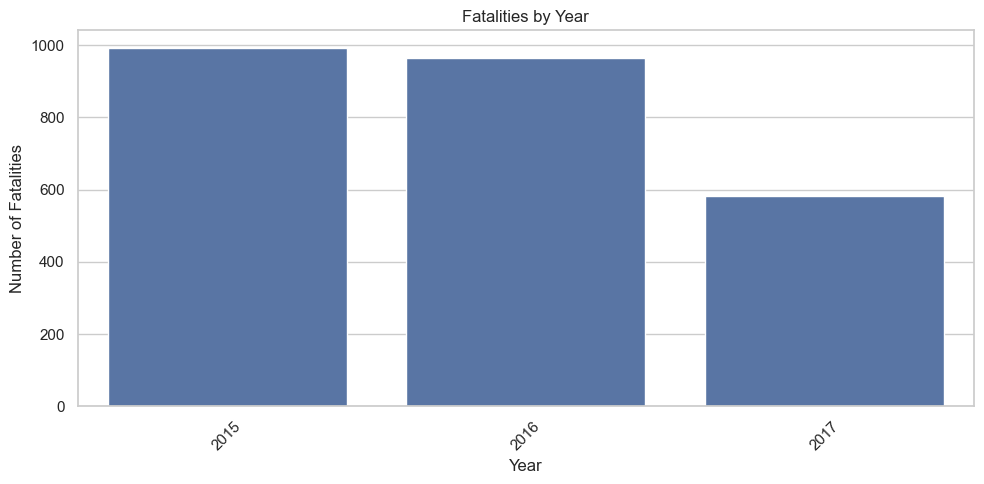

In [109]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=yearly_counts,
    x="year",
    y="fatalities"
)

plt.title("Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

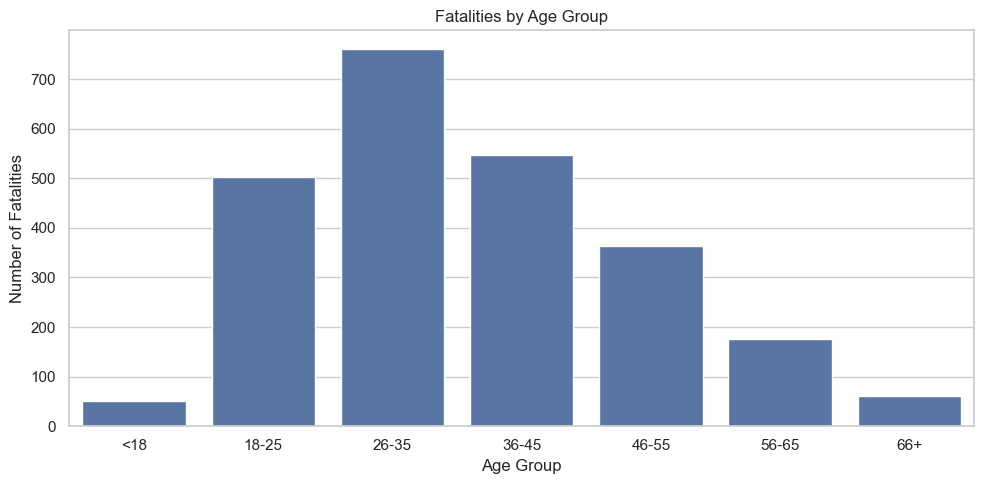

In [110]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_group_counts,
    x="age_group",
    y="fatalities"
)

plt.title("Fatalities by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Fatalities")
plt.tight_layout()
plt.show()

In [111]:
race_counts = (
    df_analysis["race"]
    .value_counts()
    .dropna()
    .reset_index()
)

race_counts.columns = ["race", "fatalities"]

race_counts

,race,fatalities
0,W,1201
1,B,618
2,H,423
3,A,39
4,N,31
5,O,28


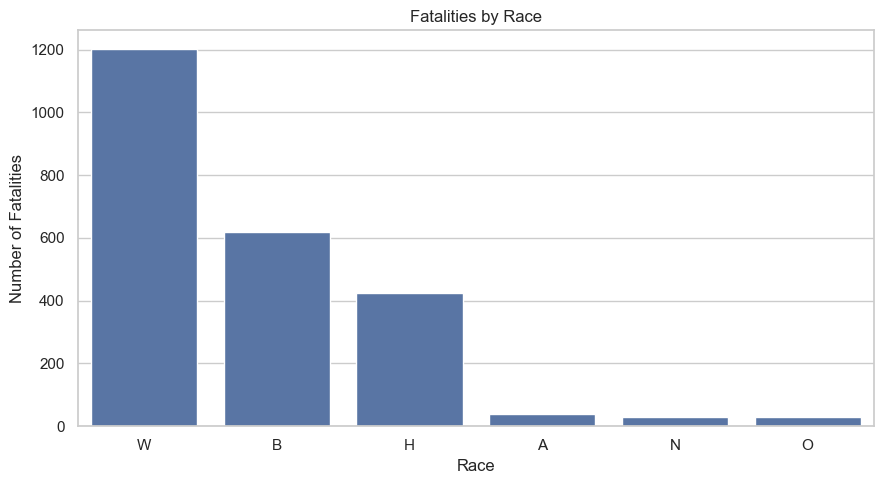

In [112]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=race_counts,
    x="race",
    y="fatalities"
)

plt.title("Fatalities by Race")
plt.xlabel("Race")
plt.ylabel("Number of Fatalities")
plt.tight_layout()
plt.show()

In [113]:
gender_counts = (
    df_analysis["gender"]
    .value_counts()
    .dropna()
    .reset_index()
)

gender_counts.columns = ["gender", "fatalities"]

gender_counts

,gender,fatalities
0,M,2428
1,F,107


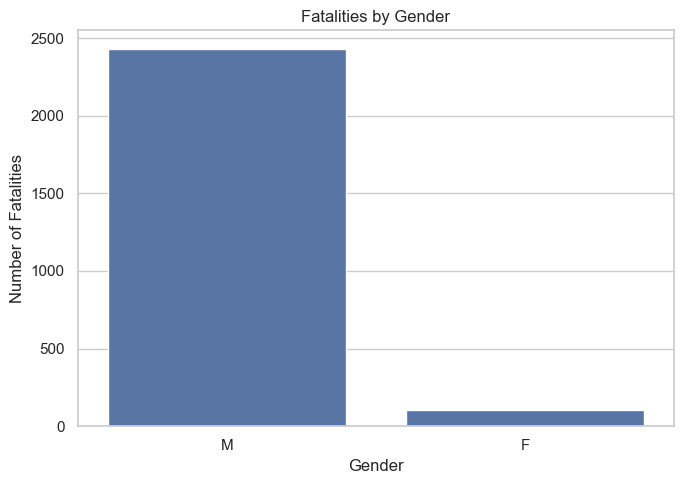

In [114]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_counts,
    x="gender",
    y="fatalities"
)

plt.title("Fatalities by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Fatalities")
plt.tight_layout()
plt.show()

In [115]:
manner_counts = (
    df_analysis["manner_of_death"]
    .value_counts()
    .dropna()
    .reset_index()
)

manner_counts.columns = ["manner_of_death", "fatalities"]

manner_counts

,manner_of_death,fatalities
0,shot,2363
1,shot and Tasered,172


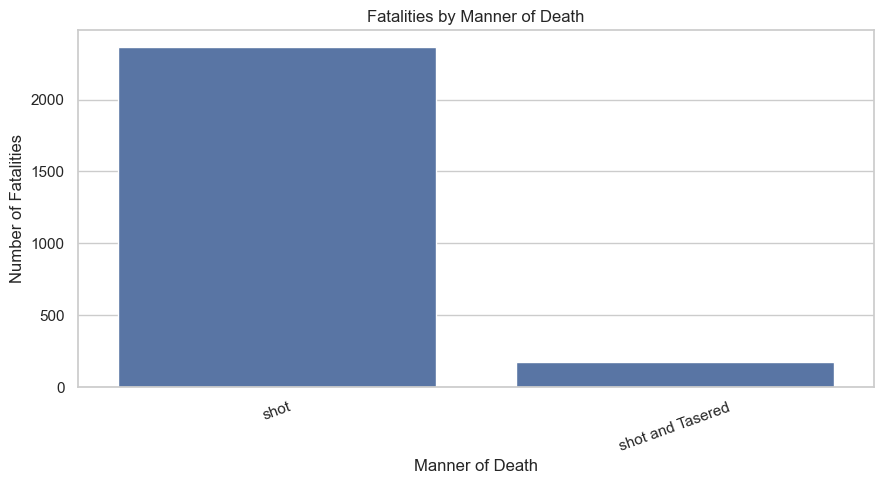

In [116]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=manner_counts,
    x="manner_of_death",
    y="fatalities"
)

plt.title("Fatalities by Manner of Death")
plt.xlabel("Manner of Death")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [117]:
threat_counts = (
    df_analysis["threat_level"]
    .value_counts()
    .dropna()
    .reset_index()
)

threat_counts.columns = ["threat_level", "fatalities"]

threat_counts

,threat_level,fatalities
0,attack,1611
1,other,766
2,undetermined,158


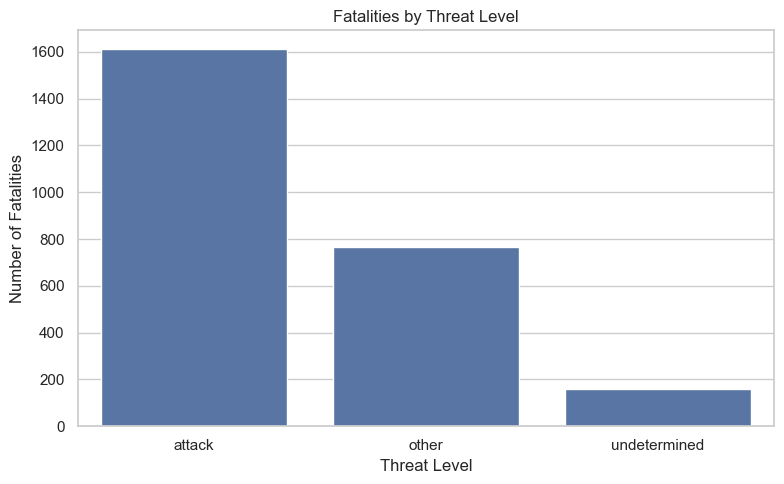

In [118]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=threat_counts,
    x="threat_level",
    y="fatalities"
)

plt.title("Fatalities by Threat Level")
plt.xlabel("Threat Level")
plt.ylabel("Number of Fatalities")
plt.tight_layout()
plt.show()

In [119]:
mental_counts = (
    df_analysis["signs_of_mental_illness"]
    .value_counts()
    .dropna()
    .reset_index()
)

mental_counts.columns = ["signs_of_mental_illness", "fatalities"]

mental_counts

,signs_of_mental_illness,fatalities
0,False,1902
1,True,633


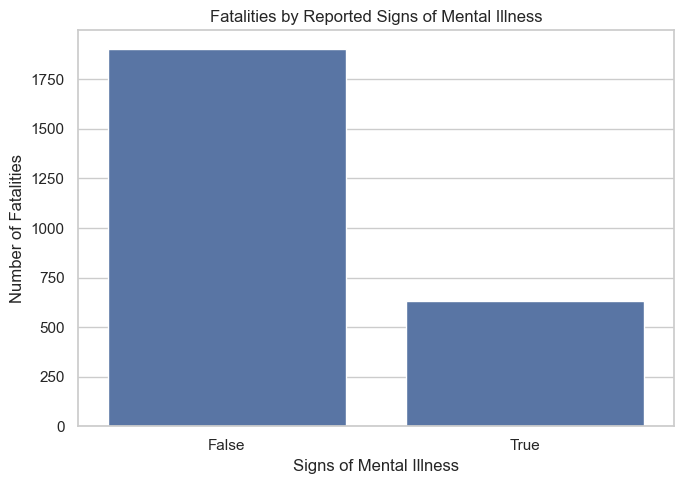

In [120]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=mental_counts,
    x="signs_of_mental_illness",
    y="fatalities"
)

plt.title("Fatalities by Reported Signs of Mental Illness")
plt.xlabel("Signs of Mental Illness")
plt.ylabel("Number of Fatalities")
plt.tight_layout()
plt.show()

In [121]:
camera_counts = (
    df_analysis["body_camera"]
    .value_counts()
    .dropna()
    .reset_index()
)

camera_counts.columns = ["body_camera", "fatalities"]

camera_counts

,body_camera,fatalities
0,False,2264
1,True,271


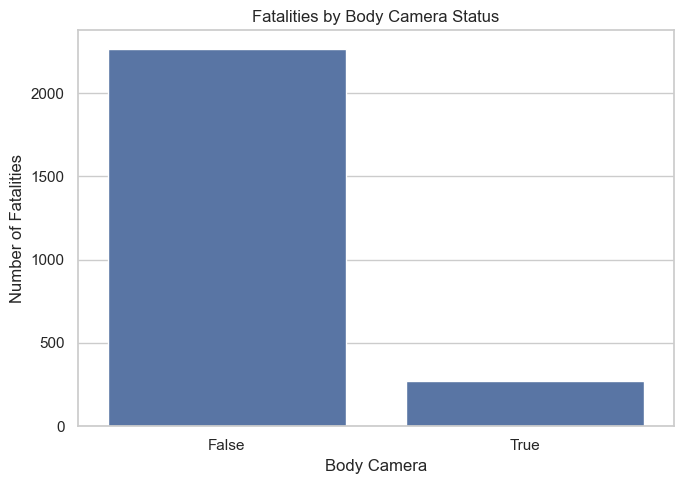

In [122]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=camera_counts,
    x="body_camera",
    y="fatalities"
)

plt.title("Fatalities by Body Camera Status")
plt.xlabel("Body Camera")
plt.ylabel("Number of Fatalities")
plt.tight_layout()
plt.show()

In [123]:
flee_counts = (
    df_analysis["flee"]
    .value_counts()
    .dropna()
    .reset_index()
)

flee_counts.columns = ["flee", "fatalities"]

flee_counts

,flee,fatalities
0,Not fleeing,1695
1,Car,385
2,Foot,294
3,Other,96


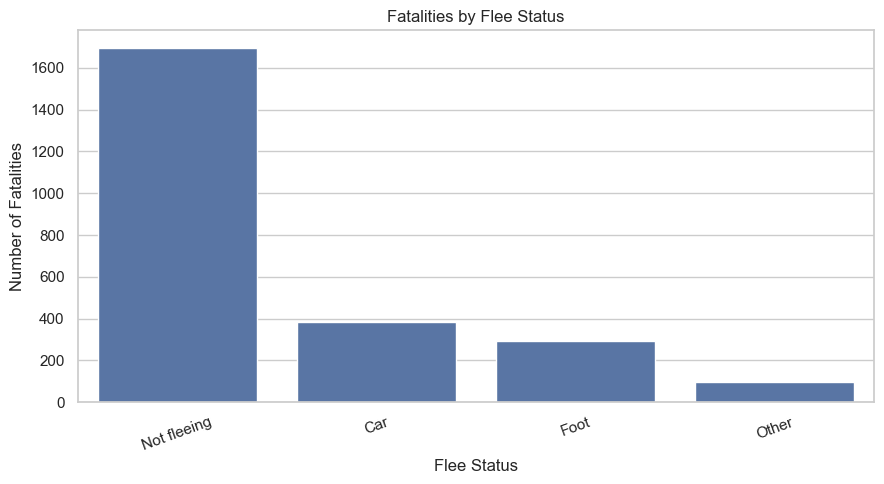

In [124]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=flee_counts,
    x="flee",
    y="fatalities"
)

plt.title("Fatalities by Flee Status")
plt.xlabel("Flee Status")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [125]:
monthly_counts["date"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" +
    monthly_counts["month"].astype(str) + "-01"
)

monthly_counts = monthly_counts.sort_values("date")

monthly_counts.head()

,year,month,fatalities,date
0,2015,1,76,2015-01-01
1,2015,2,77,2015-02-01
2,2015,3,92,2015-03-01
3,2015,4,84,2015-04-01
4,2015,5,71,2015-05-01


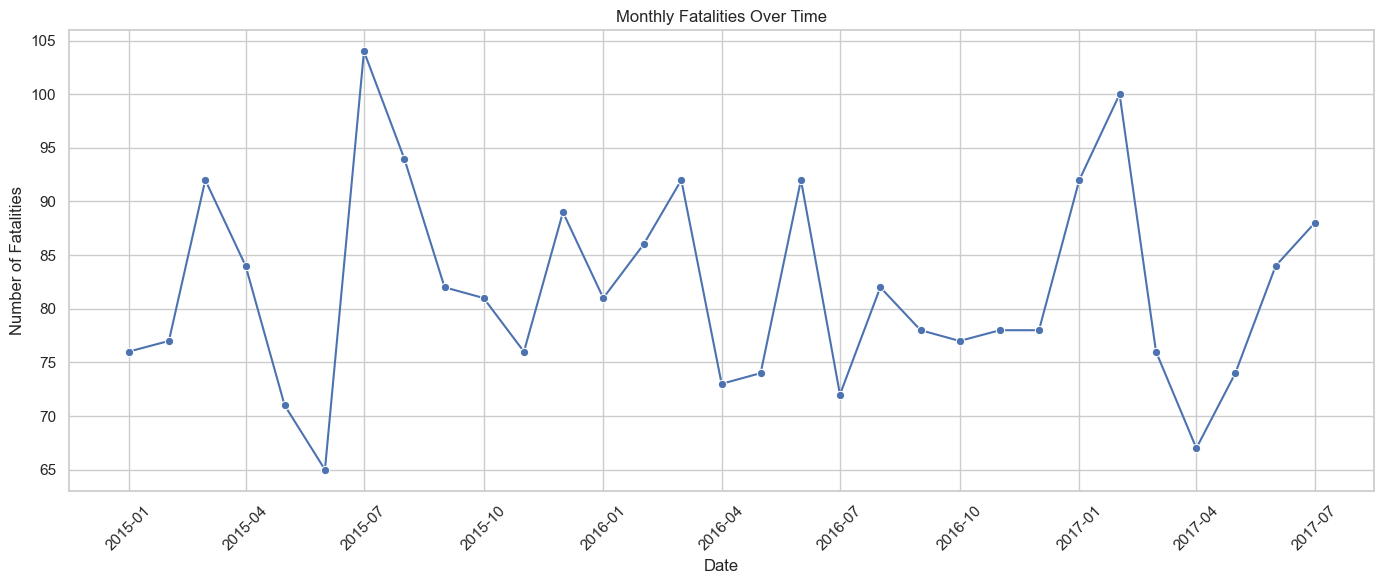

In [126]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_counts,
    x="date",
    y="fatalities",
    marker="o"
)

plt.title("Monthly Fatalities Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [127]:
yearly_counts.to_csv(
    "../data/processed/yearly_fatalities.csv",
    index=False
)

In [128]:
age_group_counts.to_csv(
    "../data/processed/age_group_fatalities.csv",
    index=False
)

In [129]:
race_counts.to_csv(
    "../data/processed/race_fatalities.csv",
    index=False
)

In [130]:
monthly_counts.to_csv(
    "../data/processed/monthly_fatalities.csv",
    index=False
)

In [131]:
# Create the canonical cleaned dataset for the project

canonical_df = df_clean.copy()

# Create simplified armed-status category
canonical_df["armed_status"] = canonical_df["armed"].apply(
    lambda x: "Unknown" if pd.isna(x)
    else "Unarmed/Unknown" if str(x).lower() in [
        "unarmed",
        "unknown",
        "undetermined"
    ]
    else "Armed"
)

# Keep the main analysis columns
canonical_df = canonical_df[
    [
        "date",
        "year",
        "month",
        "month_name",
        "day_of_week",
        "age",
        "age_group",
        "gender",
        "race",
        "threat_level",
        "flee",
        "armed",
        "armed_status",
        "manner_of_death",
        "signs_of_mental_illness",
        "body_camera",
        "state",
        "city"
    ]
].copy()

# Save canonical dataset
canonical_df.to_csv(
    "../data/processed/canonical_cleaned_data.csv",
    index=False
)

print("Canonical dataset saved successfully.")
print("Shape:", canonical_df.shape)

Canonical dataset saved successfully.
Shape: (2535, 18)
